In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split

print("✅ Imports OK")

✅ Imports OK


In [8]:
df = pd.read_csv("../data/creditcard.csv")

X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")
print(f"Fraudes dans le test : {y_test.sum()}")

Train : (227845, 29), Test : (56962, 29)
Fraudes dans le test : 98


In [9]:
contamination = y_train.sum() / len(y_train)
print(f"Taux de contamination : {contamination:.4f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)
print("✅ Modèle entraîné !")

Taux de contamination : 0.0017
✅ Modèle entraîné !


In [10]:
# Isolation Forest retourne -1 (anomalie) ou 1 (normal)
y_pred_raw = iso_forest.predict(X_test)

# Convertir : -1 → 1 (fraude), 1 → 0 (normal)
y_pred = np.where(y_pred_raw == -1, 1, 0)

# Score d'anomalie
scores = -iso_forest.score_samples(X_test)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.32      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



AUPRC (Average Precision) : 0.1714


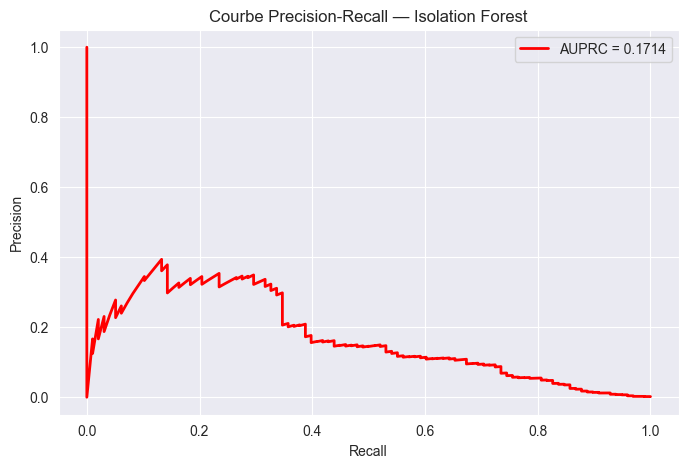

In [11]:
auprc = average_precision_score(y_test, scores)
print(f"AUPRC (Average Precision) : {auprc:.4f}")

precision, recall, thresholds = precision_recall_curve(y_test, scores)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='red', lw=2, label=f'AUPRC = {auprc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Isolation Forest')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Coût estimé
cout_FP = 10    # Faux positif = blocage inutile
cout_FN = 500   # Faux négatif = fraude non détectée

cout_total = (FP * cout_FP) + (FN * cout_FN)

print(f"Vrais Positifs (fraudes détectées)  : {TP}")
print(f"Faux Positifs (blocages injustifiés) : {FP}")
print(f"Faux Négatifs (fraudes manquées)    : {FN}")
print(f"\nCoût financier estimé : {cout_total}€")
print(f"  - FP ({FP} x {cout_FP}€) = {FP*cout_FP}€")
print(f"  - FN ({FN} x {cout_FN}€) = {FN*cout_FN}€")

Vrais Positifs (fraudes détectées)  : 32
Faux Positifs (blocages injustifiés) : 68
Faux Négatifs (fraudes manquées)    : 66

Coût financier estimé : 33680€
  - FP (68 x 10€) = 680€
  - FN (66 x 500€) = 33000€
